## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [0]:
import tensorflow as tf
tf.reset_default_graph()
tf.set_random_seed(42)

In [2]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

Using TensorFlow backend.


4423680/4422102 [==============================] - 2s 1us/step


### Find no.of samples are there in training and test datasets

In [12]:
#number of samples on the train dataset 
print(x_train.shape)

(60000, 28, 28)


In [5]:
#number of samples on the test dataset 
print(x_test.shape)

(10000, 28, 28)


### Find dimensions of an image in the dataset

In [17]:
#dimensions of an image in the dataset
x_train[1].shape

(28, 28)

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
#convert the Ytest and Ytrain to a one hot vectors 
y_train_one = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test_one = tf.keras.utils.to_categorical(y_test, num_classes=10)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
# # normalize inputs from 0-255 to 0-1
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [26]:
#convert from 60000, 28, 28 to 60000, 28, 28,1
x_train_norm = x_train_norm.reshape(60000, 28, 28,1)
x_test_norm = x_test_norm.reshape(10000, 28, 28,1)
print(x_train_norm.shape)
print(x_test_norm.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


### Import the necessary layers from keras to build the model

In [0]:
from keras.models import Sequential
from keras.layers import Dense
from keras import regularizers
from keras import optimizers

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [0]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))

#output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))


In [0]:
# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

#early stopping
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='auto', verbose=1, patience=5)
#tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5, mode='auto')


In [35]:
# Fit the model
model.fit(x_train_norm, y_train_one, epochs=10, batch_size=1000, verbose= 1,callbacks=[es])

Epoch 1/10
59000/60000 [============================>.] - ETA: 0s - loss: 0.7030 - acc: 0.7609

W0818 10:17:19.791839 140667993491328 callbacks.py:1259] Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc


60000/60000 [==============================] - 2s 37us/sample - loss: 0.6990 - acc: 0.7620
Epoch 2/10
59000/60000 [============================>.] - ETA: 0s - loss: 0.3785 - acc: 0.8657

W0818 10:17:21.660949 140667993491328 callbacks.py:1259] Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc


60000/60000 [==============================] - 2s 31us/sample - loss: 0.3774 - acc: 0.8661
Epoch 3/10
59000/60000 [============================>.] - ETA: 0s - loss: 0.3161 - acc: 0.8869

...

60000/60000 [==============================] - 2s 31us/sample - loss: 0.1948 - acc: 0.9303
Epoch 9/10
59000/60000 [============================>.] - ETA: 0s - loss: 0.1812 - acc: 0.9351

W0818 10:17:34.628333 140667993491328 callbacks.py:1259] Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc


60000/60000 [==============================] - 2s 31us/sample - loss: 0.1811 - acc: 0.9352
Epoch 10/10
59000/60000 [============================>.] - ETA: 0s - loss: 0.1706 - acc: 0.9380

W0818 10:17:36.481219 140667993491328 callbacks.py:1259] Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc


60000/60000 [==============================] - 2s 31us/sample - loss: 0.1704 - acc: 0.9382


### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [0]:
model2 = tf.keras.models.Sequential()

model2.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model2.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))

#adding maxpool layer
model2.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))

#adding dropout layer
model2.add(tf.keras.layers.Dropout(0.25))

model2.add(tf.keras.layers.Flatten())
model2.add(tf.keras.layers.Dense(128, activation='relu'))

#output layer
model2.add(tf.keras.layers.Dense(10, activation='softmax'))

In [0]:
# Compile model
model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

#early stopping
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='auto', verbose=1, patience=5)
#tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5, mode='auto')

In [39]:
# Fit the model
model2.fit(x_train_norm, y_train_one, epochs=10, batch_size=1000, verbose= 1,callbacks=[es])

Epoch 1/10
59000/60000 [============================>.] - ETA: 0s - loss: 0.7530 - acc: 0.7381

W0818 10:25:23.235937 140667993491328 callbacks.py:1259] Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc


60000/60000 [==============================] - 2s 34us/sample - loss: 0.7486 - acc: 0.7396
Epoch 2/10
59000/60000 [============================>.] - ETA: 0s - loss: 0.4300 - acc: 0.8478

W0818 10:25:25.044036 140667993491328 callbacks.py:1259] Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc


60000/60000 [==============================] - 2s 30us/sample - loss: 0.4293 - acc: 0.8479
Epoch 3/10
59000/60000 [============================>.] - ETA: 0s - loss: 0.3677 - acc: 0.8702

...

60000/60000 [==============================] - 2s 30us/sample - loss: 0.2591 - acc: 0.9070
Epoch 9/10
59000/60000 [============================>.] - ETA: 0s - loss: 0.2465 - acc: 0.9114

W0818 10:25:37.657242 140667993491328 callbacks.py:1259] Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc


60000/60000 [==============================] - 2s 30us/sample - loss: 0.2468 - acc: 0.9114
Epoch 10/10
59000/60000 [============================>.] - ETA: 0s - loss: 0.2340 - acc: 0.9151

W0818 10:25:39.446762 140667993491328 callbacks.py:1259] Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc


60000/60000 [==============================] - 2s 30us/sample - loss: 0.2343 - acc: 0.9150


### Now, to the above model, lets add Data Augmentation 

#Define some parameters
# Import the ImageDataGenrator from keras and fit the training images

In [65]:
from keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rotation_range=20,width_shift_range=0.2,height_shift_range=0.2,horizontal_flip=True)
datagen.fit(x_train_norm)

/usr/local/lib/python3.6/dist-packages/keras_preprocessing/image/image_data_generator.py:940: UserWarning: Expected input to be images (as Numpy array) following the data format convention "channels_first" (channels on axis 1), i.e. expected either 1, 3 or 4 channels on axis 1. However, it was passed an array with shape (60000, 28, 28, 1) (28 channels).
  ' channels).')


In [62]:
for e in range(10):
    print('Epoch', e)
    batches = 0
    for x_batch, y_batch in datagen.flow(x_train_norm, y_train_one, batch_size=32):
        model2.fit(x_batch, y_batch)
        batches += 1
        if batches >= len(x_train_norm) / 32:
            # we need to break the loop by hand because
            # the generator loops indefinitely
            break

Epoch 0
32/32 [==============================] - 0s 322us/sample - loss: 0.4914 - acc: 0.8125


/usr/local/lib/python3.6/dist-packages/keras_preprocessing/image/numpy_array_iterator.py:127: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_first" (channels on axis 1), i.e. expected either 1, 3, or 4 channels on axis 1. However, it was passed an array with shape (60000, 28, 28, 1) (28 channels).
  str(self.x.shape[channels_axis]) + ' channels).')


32/32 [==============================] - 0s 134us/sample - loss: 0.1330 - acc: 0.9688
Epoch 1
32/32 [==============================] - 0s 155us/sample - loss: 0.3606 - acc: 0.8438


KeyboardInterrupt: ignored

/usr/local/lib/python3.6/dist-packages/keras_preprocessing/image/numpy_array_iterator.py:127: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_first" (channels on axis 1), i.e. expected either 1, 3, or 4 channels on axis 1. However, it was passed an array with shape (60000, 28, 28, 1) (28 channels).
  str(self.x.shape[channels_axis]) + ' channels).')


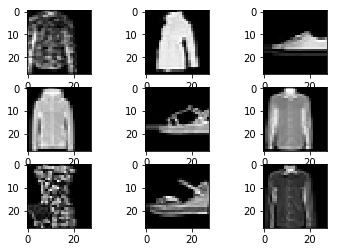

In [66]:
#after applying image generator transform

for X_batch, y_batch in datagen.flow(x_train_norm, y_train_one, batch_size=9):
	# create a grid of 3x3 images
	for i in range(0, 9):
		pyplot.subplot(330 + 1 + i)
		pyplot.imshow(X_batch[i].reshape(28, 28), cmap=pyplot.get_cmap('gray'))
	# show the plot
	pyplot.show()
	break

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

/usr/local/lib/python3.6/dist-packages/keras_preprocessing/image/numpy_array_iterator.py:127: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_first" (channels on axis 1), i.e. expected either 1, 3, or 4 channels on axis 1. However, it was passed an array with shape (1, 28, 28, 1) (28 channels).
  str(self.x.shape[channels_axis]) + ' channels).')


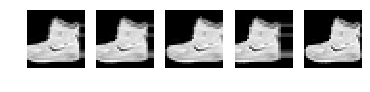

In [67]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train_norm[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [68]:
# fits the model on batches with real-time data augmentation:
model2.fit_generator(datagen.flow(x_train_norm, y_train_one, batch_size=32),steps_per_epoch=len(x_train) / 32, epochs=10)


Epoch 1/10
   7/1875 [..............................] - ETA: 50s - loss: 0.2056 - acc: 0.9286

/usr/local/lib/python3.6/dist-packages/keras_preprocessing/image/numpy_array_iterator.py:127: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_first" (channels on axis 1), i.e. expected either 1, 3, or 4 channels on axis 1. However, it was passed an array with shape (60000, 28, 28, 1) (28 channels).
  str(self.x.shape[channels_axis]) + ' channels).')


1875/1875 [==============================] - 50s 27ms/step - loss: 0.2047 - acc: 0.9242
Epoch 2/10
1875/1875 [==============================] - 50s 27ms/step - loss: 0.1983 - acc: 0.9273
Epoch 3/10
1875/1875 [==============================] - 51s 27ms/step - loss: 0.1942 - acc: 0.9274
Epoch 4/10
1875/1875 [==============================] - 50s 27ms/step - loss: 0.1910 - acc: 0.9298
Epoch 5/10
1875/1875 [==============================] - 51s 27ms/step - loss: 0.1895 - acc: 0.9295
Epoch 6/10
1875/1875 [==============================] - 51s 27ms/step - loss: 0.1874 - acc: 0.9300
Epoch 7/10
1875/1875 [==============================] - 51s 27ms/step - loss: 0.1831 - acc: 0.9327
Epoch 8/10
1875/1875 [==============================] - 51s 27ms/step - loss: 0.1763 - acc: 0.9338
Epoch 9/10
1875/1875 [==============================] - 51s 27ms/step - loss: 0.1789 - acc: 0.9341
Epoch 10/10
1875/1875 [==============================] - 51s 27ms/step - loss: 0.1725 - acc: 0.9359


In [70]:
# fits the model on batches with real-time data augmentation:
model2.fit_generator(datagen.flow(x_test_norm, y_test_one, batch_size=32),steps_per_epoch=len(x_train) / 32, epochs=10)

Epoch 1/10
   5/1875 [..............................] - ETA: 54s - loss: 0.2189 - acc: 0.8938

/usr/local/lib/python3.6/dist-packages/keras_preprocessing/image/numpy_array_iterator.py:127: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_first" (channels on axis 1), i.e. expected either 1, 3, or 4 channels on axis 1. However, it was passed an array with shape (10000, 28, 28, 1) (28 channels).
  str(self.x.shape[channels_axis]) + ' channels).')


1875/1875 [==============================] - 51s 27ms/step - loss: 0.2275 - acc: 0.9181
Epoch 2/10
1875/1875 [==============================] - 51s 27ms/step - loss: 0.1781 - acc: 0.9364
Epoch 3/10
1875/1875 [==============================] - 50s 27ms/step - loss: 0.1522 - acc: 0.9442
Epoch 4/10
1875/1875 [==============================] - 51s 27ms/step - loss: 0.1268 - acc: 0.9535
Epoch 5/10
1875/1875 [==============================] - 51s 27ms/step - loss: 0.1104 - acc: 0.9597
Epoch 6/10
1875/1875 [==============================] - 50s 27ms/step - loss: 0.0948 - acc: 0.9652
Epoch 7/10
1875/1875 [==============================] - 51s 27ms/step - loss: 0.0876 - acc: 0.9674
Epoch 8/10
1875/1875 [==============================] - 50s 27ms/step - loss: 0.0765 - acc: 0.9718
Epoch 9/10
1875/1875 [==============================] - 50s 27ms/step - loss: 0.0688 - acc: 0.9751
Epoch 10/10
1875/1875 [==============================] - 50s 27ms/step - loss: 0.0621 - acc: 0.9770


###  Report the final train and validation accuracy

In [73]:
score_train = model2.evaluate(x_train_norm, y_train_one, verbose=0)
print(score_train)

[0.2834123282193517, 0.9241833]


In [74]:
score_test = model2.evaluate(x_test_norm, y_test_one, verbose=0)
print(score_test)

[0.03223229674100876, 0.9888]


## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [3]:
import keras
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, Lambda, MaxPooling2D
from keras import backend as K
%matplotlib inline
import os

Using TensorFlow backend.


### **Load CIFAR10 dataset**

In [4]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170500096/170498071 [==============================] - 2s 0us/step


In [5]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [6]:
x_train

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

In [7]:
# # normalize inputs from 0-255 to 0-1
x_train = x_train / 255
#x_test = x_test / 255

#x_train = x_train.astype('float32')
#x_test = x_test.astype('float32')
x_train

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
transform_fn = tf.keras.preprocessing.image.ImageDataGenerator(horizontal_flip=True,
                                                               width_shift_range=0.2,
                                                               height_shift_range=0.2,
                                                               rotation_range=30,
                                                               shear_range=0.2,
                                                               zoom_range=0.3)

### **Prepare/fit the generator.**

In [11]:
transform_fn.fit(x_train)
x_train[0:1]

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

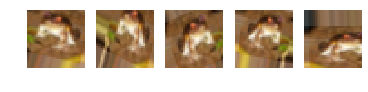

In [12]:
from matplotlib import pyplot as plt
gen = transform_fn.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()